# 04 — Supervised Learning: Regression & Revenue Simulator

This notebook handles the regression task specified in Phase 2 (Section 5.3) of the project. The goal is to predict a customer's future spend based on their historical behavior.

Per the project specification, this notebook establishes our operational definition for the regression target to avoid data leakage:
- **Features**: Customer metrics (Recency, Frequency, Monetary, etc.) calculated strictly over months 1–9 of the dataset.
- **Target**: The total Monetary value (spend) for that exact same customer during the remaining period of the year (months 10–12+).

This notebook trains and evaluates two models using the fixed 80/10/10 customer-level split:
1. **Model 1 (Required)**: A Feed-Forward Neural Network Regressor (`MLPRegressor`) with a minimum architecture of Input -> Dense(32, ReLU) -> Dense(16, ReLU) -> Dense(1, Linear).
2. **Model 2 (Baseline)**: A standard Linear Regression model.

**Handoff to Phase 3 (Section 5.4):**
The best-performing model is saved as a serialized artifact (`models/regression_simulator.pkl`). This artifact will serve as the "simulated environment transition function" (revenue simulator) for the Reinforcement Learning agent in `05_qlearning_dqn.ipynb` and for the `app.py` GUI.

In [1]:
# --- Imports & Setup ---
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Directory setup
DATA_DIR = Path("../data")
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Random state for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load Data and Apply Fixed Customer Split

We load `customer_features_regression.csv` and the fixed `customer_split_ids.pkl` generated in `01_data_preprocessing.ipynb`. This ensures we are using the exact same 80/10/10 training, validation, and testing splits as the classification task.

**Handling Multicollinearity:**
Since the six category spend percentages sum to 100%, they are perfectly collinear. We drop `Other` as the reference category and keep the remaining 5 categories (`Homeware`, `Stationery`, `Gadgets`, `Decorations`, `Kitchenware`).
Unlike the classification task where `Monetary` was excluded to avoid a circular definition (since the `High-Value` label was a direct threshold on `Monetary`), we **keep** `Monetary` as a regression feature. A customer's past spend is a strong predictor of their future spend.

In [2]:
# Load the engineered regression features
features_df = pd.read_csv(DATA_DIR / "customer_features_regression.csv")
features_df = features_df.set_index("CustomerID")

# Target column name from Notebook 01
TARGET_COL = "Target_Monetary"

# Input features (excluding the redundant 'Other' category and the target)
FEATURE_COLUMNS = [
    "Monetary", "Recency", "Frequency", "Product_Diversity", "Avg_Spend_Trans",
    "Homeware", "Stationery", "Gadgets", "Decorations", "Kitchenware"
]

X = features_df[FEATURE_COLUMNS]
y = features_df[TARGET_COL]

# Load the fixed train/val/test splits (Section 5.1)
split_ids = joblib.load(MODELS_DIR / "customer_split_ids.pkl")

# Align split IDs with regression features index (only customers active in months 1-9 are present)
train_ids = [cid for cid in split_ids["train_ids"] if cid in X.index]
val_ids   = [cid for cid in split_ids["val_ids"] if cid in X.index]
test_ids  = [cid for cid in split_ids["test_ids"] if cid in X.index]

# Filter the data based on the split IDs
X_train = X.loc[train_ids]
y_train = y.loc[train_ids]

X_val = X.loc[val_ids]
y_val = y.loc[val_ids]

X_test = X.loc[test_ids]
y_test = y.loc[test_ids]

print(f"Total customers in regression set: {X.shape[0]}")
print(f"Training set:   {X_train.shape[0]} customers")
print(f"Validation set: {X_val.shape[0]} customers")
print(f"Test set:       {X_test.shape[0]} customers")

Total customers in regression set: 3317
Training set:   2656 customers
Validation set: 321 customers
Test set:       340 customers


## 2. Model Training and Validation

We will build scikit-learn `Pipeline`s for both models. Including a `StandardScaler` inside the pipeline is critical because:
1. Distance-based models and Neural Networks perform poorly on unscaled data (e.g., `Monetary` is much larger than `Frequency`).
2. Packaging the scaler with the model ensures that Phase 3 (RL) and Phase 7 (GUI) will automatically scale raw inputs correctly without needing a separate scaler object.

In [3]:
# --- Model 2: Linear Regression (Baseline) ---
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])
lr_pipeline.fit(X_train, y_train)

lr_val_preds = lr_pipeline.predict(X_val)
lr_val_rmse = np.sqrt(mean_squared_error(y_val, lr_val_preds))


# --- Model 1: Feed-Forward Neural Network (MLP) ---
# Architecture specified in 5.3: Dense(32, ReLU) -> Dense(16, ReLU) -> Linear Output
mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", MLPRegressor(
        hidden_layer_sizes=(32, 16),
        activation="relu",
        solver="adam",
        max_iter=1000,          # High iteration limit to ensure convergence
        early_stopping=True,    # Prevents overfitting on training set
        random_state=RANDOM_STATE
    ))
])
mlp_pipeline.fit(X_train, y_train)

mlp_val_preds = mlp_pipeline.predict(X_val)
mlp_val_rmse = np.sqrt(mean_squared_error(y_val, mlp_val_preds))

print("--- Validation Set Performance ---")
print(f"Linear Regression RMSE: ${lr_val_rmse:.2f}")
print(f"Neural Network RMSE:    ${mlp_val_rmse:.2f}")

--- Validation Set Performance ---
Linear Regression RMSE: $1869.40
Neural Network RMSE:    $1572.86


## 3. Final Evaluation on Test Set

Based on the validation results, we evaluate both models on the held-out test set to report MSE, RMSE, and $R^2$. We also plot the predicted vs. actual values to visually inspect the model's accuracy.

--- Linear Regression Test Metrics ---
MSE:  3305353.48
RMSE: $1818.06
R²:   0.5771



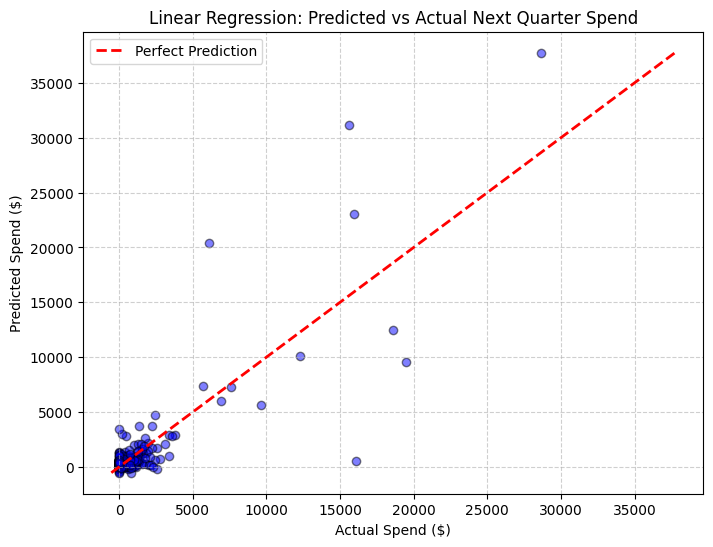

--- Feed-Forward Neural Network Test Metrics ---
MSE:  3081273.63
RMSE: $1755.36
R²:   0.6057



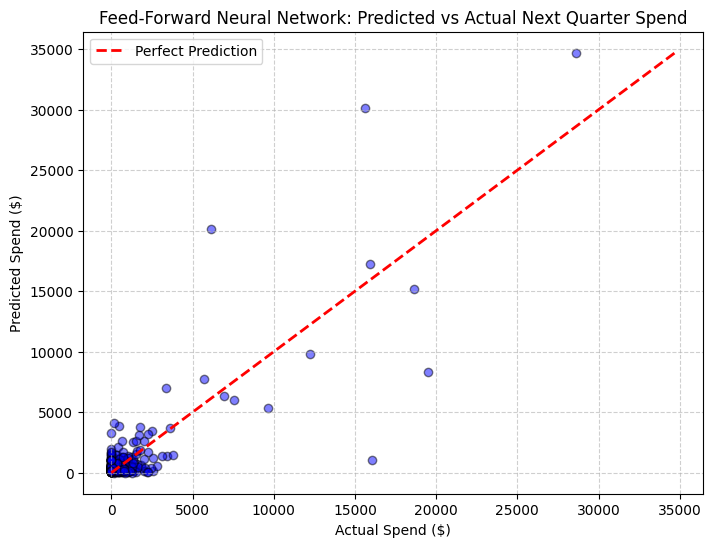

In [4]:
def evaluate_and_plot(model, model_name, X_test, y_test):
    """Generates test metrics and predicted vs actual scatter plot."""
    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)

    print(f"--- {model_name} Test Metrics ---")
    print(f"MSE:  {mse:.2f}")
    print(f"RMSE: ${rmse:.2f}")
    print(f"R²:   {r2:.4f}\n")

    # Predicted vs Actual Scatter Plot (Section 5.3)
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, preds, alpha=0.5, color='blue', edgecolor='k')

    # Plot perfect prediction diagonal line
    max_val = max(y_test.max(), preds.max())
    min_val = min(y_test.min(), preds.min())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label="Perfect Prediction")

    plt.title(f"{model_name}: Predicted vs Actual Next Quarter Spend")
    plt.xlabel("Actual Spend ($)")
    plt.ylabel("Predicted Spend ($)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Evaluate Baseline
evaluate_and_plot(lr_pipeline, "Linear Regression", X_test, y_test)

# Evaluate MLP
evaluate_and_plot(mlp_pipeline, "Feed-Forward Neural Network", X_test, y_test)

## 4. Phase 3 Handoff (Model Artifact)

The project specification (Section 5.4) requires saving the regression model so it can be imported as the simulated transition function/revenue simulator for the RL agent in Phase 3, and for user-facing inference in `app.py`.

We will select the pipeline that performed best on the validation set and save it to the `models/` directory.

In [5]:
# Determine the best model based on validation RMSE
best_model = mlp_pipeline if mlp_val_rmse < lr_val_rmse else lr_pipeline
best_model_name = "Neural Network" if mlp_val_rmse < lr_val_rmse else "Linear Regression"

print(f"Selected {best_model_name} as the final revenue simulator.")

# Save the full pipeline (Scaler + Regressor) as a single artifact
artifact_path = MODELS_DIR / "regression_simulator.pkl"
joblib.dump(best_model, artifact_path)
print(f"Model successfully saved to: {artifact_path}")

Selected Neural Network as the final revenue simulator.
Model successfully saved to: ..\models\regression_simulator.pkl


## 5. Artifacts saved by this notebook

| File | Description |
|---|---|
| `models/regression_simulator.pkl` | Serialized scikit-learn Pipeline (`StandardScaler` + `MLPRegressor` or `LinearRegression`) representing the best-performing revenue simulator model, ready for environment transition function simulation in Phase 3 RL and GUI inference. |

**Next notebook:** `05_qlearning_dqn.ipynb` will load the environment transition function (`models/regression_simulator.pkl`) and train a Reinforcement Learning agent to optimize marketing campaign spend over a customer's lifetime.